In [4]:
import pandas as pd
sale_dt = pd.read_csv("Sales Data.csv", index_col=0)
# sale_dt.head()
sale_dt.info()
sale_dt.describe()

<class 'pandas.DataFrame'>
Index: 185950 entries, 0 to 13621
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order ID          185950 non-null  int64  
 1   Product           185950 non-null  str    
 2   Quantity Ordered  185950 non-null  int64  
 3   Price Each        185950 non-null  float64
 4   Order Date        185950 non-null  str    
 5   Purchase Address  185950 non-null  str    
 6   Month             185950 non-null  int64  
 7   Sales             185950 non-null  float64
 8   City              185950 non-null  str    
 9   Hour              185950 non-null  int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 15.6 MB


,Order ID,Quantity Ordered,Price Each,Month,Sales,Hour
count,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000
mean,230417.569379,1.124383,184.399735,7.059140,185.490917,14.413305
std,51512.737110,0.442793,332.731330,3.502996,332.919771,5.423416
min,141234.000000,1.000000,2.990000,1.000000,2.990000,0.000000
25%,185831.250000,1.000000,11.950000,4.000000,11.950000,11.000000
50%,230367.500000,1.000000,14.950000,7.000000,14.950000,15.000000
75%,275035.750000,1.000000,150.000000,10.000000,150.000000,19.000000
max,319670.000000,9.000000,1700.000000,12.000000,3400.000000,23.000000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Ready to visualize! 🔥")

Ready to visualize! 🔥


In [6]:
# What was the total revenue overall?
total_revenue = sale_dt['Sales'].sum()
print("total revenue = ", total_revenue)

total revenue =  34492035.97


In [67]:
# Which month had the highest sales?
hs_by_month = sale_dt.groupby('Month').Sales.sum()
print(hs_by_month.sort_values(ascending=False))
print(hs_by_month.idxmax() ,"th month had the highest sales")

Month
12    4613443.34
10    3736726.88
4     3390670.24
11    3199603.20
5     3152606.75
3     2807100.38
7     2647775.76
6     2577802.26
8     2244467.88
2     2202022.42
9     2097560.13
1     1822256.73
Name: Sales, dtype: float64
12 th month had the highest sales


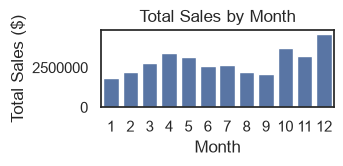

In [18]:
sns.set_theme(style='white')
plt.figure(figsize=(3, 1))
sns.barplot(x=hs_by_month.index, y=hs_by_month.values)
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.ticklabel_format(style='plain', axis='y')  # ← add this line
plt.show()

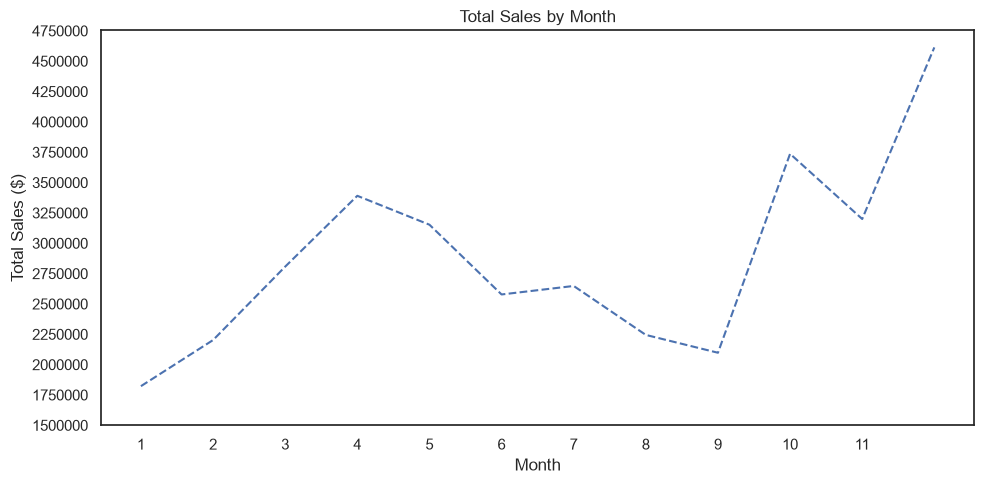

In [83]:
sns.set_theme(style='white')
plt.figure(figsize=(10, 5))
sns.lineplot(x= hs_by_month.index, y= hs_by_month.values, linestyle ='--')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(range(1,12,1)) 
plt.yticks(range(1500000,5000000,250000)) 
plt.tight_layout()
plt.show()

In [35]:
# Which product sold the most (by quantity)?
hot_pd = sale_dt.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)
print(hot_pd)
print('the product sold the most =',hot_pd.idxmax())

Product
AAA Batteries (4-pack)        31017
AA Batteries (4-pack)         27635
USB-C Charging Cable          23975
Lightning Charging Cable      23217
Wired Headphones              20557
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
27in FHD Monitor               7550
iPhone                         6849
27in 4K Gaming Monitor         6244
34in Ultrawide Monitor         6199
Google Phone                   5532
Flatscreen TV                  4819
Macbook Pro Laptop             4728
ThinkPad Laptop                4130
20in Monitor                   4129
Vareebadd Phone                2068
LG Washing Machine              666
LG Dryer                        646
Name: Quantity Ordered, dtype: int64
the product sold the most = AAA Batteries (4-pack)


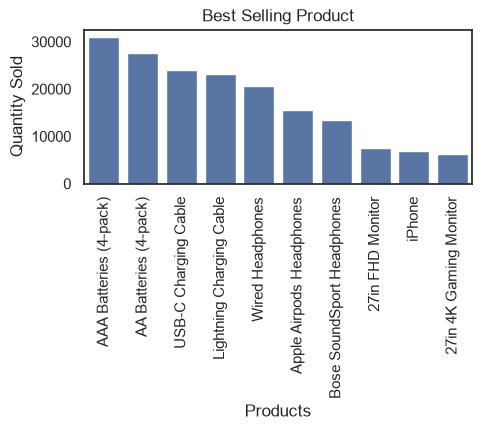

In [48]:
sns.set_theme(style='white')
plt.figure(figsize=(5, 2))
sns.barplot(x=hot_pd.index, y=hot_pd.values, order= hot_pd.head(10).index)
plt.title('Best Selling Product')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90) 
plt.show()

In [38]:
# Which city had the highest revenue?
highest_revenue_bycity = sale_dt.groupby('City').Sales.sum().sort_values(ascending=False)
print(highest_revenue_bycity)
print(highest_revenue_bycity.idxmax(), 'had the highest revenue')

City
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           2767975.40
Seattle          2747755.48
Portland         2320490.61
Austin           1819581.75
Name: Sales, dtype: float64
 San Francisco had the highest revenue


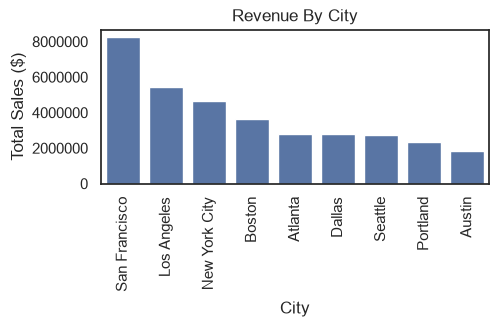

In [41]:
sns.set_theme(style='white')
plt.figure(figsize=(5, 2))
sns.barplot(x=highest_revenue_bycity.index, y=highest_revenue_bycity.values, order= highest_revenue_bycity.index)
plt.title('Revenue By City')
plt.xlabel('City')
plt.ylabel('Total Sales ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90) 
plt.show()

In [44]:
# What hour of the day do most orders happen?
# sale_dt['Order Date'] = pd.to_datetime(sale_dt['Order Date']) <<< Learn how to use it later, NO NEED RIGHT NOW
hour_by_orders = sale_dt.groupby('Hour')['Order ID'].count()
print(hour_by_orders.sort_values(ascending=False))
print("At",hour_by_orders.idxmax(), ",most orders happened")

Hour
19    12905
12    12587
11    12411
18    12280
20    12228
13    12129
14    10984
10    10944
21    10921
17    10899
16    10384
15    10175
22     8822
9      8748
23     6275
8      6256
7      4011
0      3910
6      2482
1      2350
5      1321
2      1243
4       854
3       831
Name: Order ID, dtype: int64
At 19 ,most orders happened


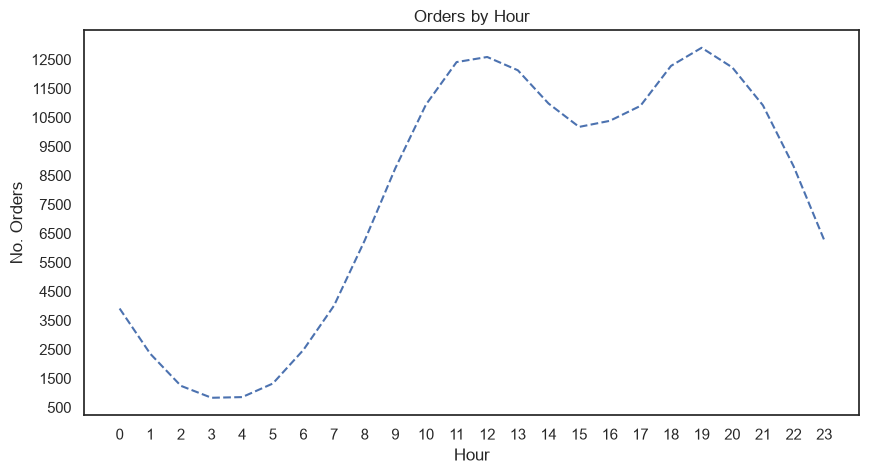

In [ ]:
sns.set_theme(style='white')
plt.figure(figsize=(10, 5))
sns.lineplot(x= hour_by_orders.index, y= hour_by_orders.values, linestyle ='--')
plt.title('Orders by Hour')
plt.xlabel('Hour')
plt.ylabel('No. Orders')
plt.xticks(range(0,24,1)) #->range(x,y,z) mean x:y Frequence by z
plt.yticks(range(500,13000,1000)) # use for change tick in y
plt.show()